# Part #2 - DP: Autonomous Drone Rescue Using Dynamic Programming
## Group Number: 223
## Group/Student Parameter Target Profile: Last Digit = 3 (5x5 Grid Layout)

In [ ]:
# ==============================================================================
# MANDATORY RUNTIME ENVIRONMENT HEADERS & METADATA
# ==============================================================================
import datetime
import socket
import platform

print("=" * 60)
print(f"Execution Timestamp: {datetime.datetime.now()}")
print(f"Machine Name / Hostname: {socket.gethostname()}")
print(f"Processor Architecture: {platform.processor()}")
print(f"Operating System: {platform.system()} {platform.release()}")
print("=" * 60)

Execution Timestamp: 2026-06-06 06:24:13.375004
Machine Name / Hostname: blue-nbjupyterhub23
Processor Architecture: x86_64
Operating System: Linux 6.8.0-1044-aws


In [ ]:
# ==============================================================================
# TASK 1: THE DRONE RESCUE MDP ENVIRONMENT INITIALIZATION
# ==============================================================================
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import time

# Environmental configuration mapping rules for a Student ID ending in 3
GRID_SIZE = 5
NUM_RESCUE = 2
NUM_CHARGING = 1
NUM_DANGER = 3
NUM_BLOCKED = 2
WIND_PROB = 0.20
MAX_BATTERY = 15     # Odd structural digit allocation rule
MAX_STEPS = 50       # Grid dimension step ceiling constraint

# Action space dictionary maps
ACTIONS = ['UP', 'DOWN', 'LEFT', 'RIGHT', 'HOVER']
ACTION_VECTORS = {
    'UP': (-1, 0),
    'DOWN': (1, 0),
    'LEFT': (0, -1),
    'RIGHT': (0, 1),
    'HOVER': (0, 0)
}

# Define static, reproducible grid location mappings
RESCUE_POSITIONS = [(1, 2), (3, 4)]
CHARGING_POSITIONS = [(2, 2)]
DANGER_POSITIONS = [(1, 1), (3, 2), (4, 3)]
BLOCKED_CELLS = [(0, 3), (2, 4)]
WIND_CELLS = [(2, 1), (1, 3)]
START_POSITION = (0, 0)

# Build a visual representation layout tracker map matrix
grid_representation = np.full((GRID_SIZE, GRID_SIZE), 'F', dtype=object)
grid_representation[START_POSITION] = 'S'
for pos in RESCUE_POSITIONS: grid_representation[pos] = 'R'
for pos in CHARGING_POSITIONS: grid_representation[pos] = 'C'
for pos in DANGER_POSITIONS: grid_representation[pos] = 'D'
for pos in BLOCKED_CELLS: grid_representation[pos] = 'X'
for pos in WIND_CELLS: grid_representation[pos] = 'W'

print("Initialized Structured Environment Model Map Layout:")
print(grid_representation)

Initialized Structured Environment Model Map Layout:
[['S' 'F' 'F' 'X' 'F']
 ['F' 'D' 'R' 'W' 'F']
 ['F' 'W' 'C' 'F' 'X']
 ['F' 'F' 'D' 'F' 'R']
 ['F' 'F' 'F' 'D' 'F']]


In [ ]:
# ==============================================================================
# STATE SPACE ENUMERATION & COMPILATION
# ==============================================================================
# Enumerate all valid state configurations. State layout: (drone_pos_tuple, battery, targets_status_tuple)
states = []

for r in range(GRID_SIZE):
    for c in range(GRID_SIZE):
        # Filter out states inside blocked cells
        if (r, c) in BLOCKED_CELLS:
            continue
        for b in range(MAX_BATTERY + 1):
            # Target combinations tracking: 1 = active, 0 = collected
            for t1 in [0, 1]:
                for t2 in [0, 1]:
                    states.append(((r, c), b, (t1, t2)))

# Generate fast lookup maps
state_to_idx = {s: i for i, s in enumerate(states)}
num_states = len(states)
print(f"Total Valid State Spaces Enumerated for Grid: {num_states} structural elements.")

Total Valid State Spaces Enumerated for Grid: 1472 structural elements.


In [ ]:
# ==============================================================================
# MDP TRANSITION DYNAMICS AND REWARD EVALUATION FUNCTION
# ==============================================================================
def calculate_state_transitions(current_state, chosen_action):
    """
    Computes potential state transitions, probabilities, and rewards for an action.
    Handles wind adjustments, boundary bounces, and target collections.
    """
    (r, c), b, targets = current_state
    
    # Terminal verification check (no battery left or all targets rescued)
    if b == 0 or sum(targets) == 0:
        return [(current_state, 1.0, 0)]
        
    intended_moves = [chosen_action]
    move_probabilities = [1.0]
    
    # Apply stochastic adjustments if the drone is on a wind cell
    if (r, c) in WIND_CELLS and chosen_action in ['UP', 'DOWN', 'LEFT', 'RIGHT']:
        intended_moves = ['UP', 'DOWN', 'LEFT', 'RIGHT']
        move_probabilities = [WIND_PROB / 4.0] * 4
        # Add intentional directional balance vector
        intended_moves.append(chosen_action)
        move_probabilities.append(1.0 - WIND_PROB)
        
    compiled_outcomes = {}
    
    for action_step, prob in zip(intended_moves, move_probabilities):
        if prob == 0.0:
            continue
            
        dr, dc = ACTION_VECTORS[action_step]
        new_r, new_c = r + dr, c + dc
        
        # Grid boundaries and blocked cells check
        if new_r < 0 or new_r >= GRID_SIZE or new_c < 0 or new_c >= GRID_SIZE or (new_r, new_c) in BLOCKED_CELLS:
            new_r, new_c = r, c  # Bounce back to previous coordinates
            
        # Standard battery reduction cost
        new_b = b - 1
        
        # Handle custom station recharge hovering rule
        if action_step == 'HOVER' and (r, c) in CHARGING_POSITIONS:
            new_b = min(MAX_BATTERY, b + 2)
            
        if new_b < 0:
            new_b = 0
            
        # Replenish battery when moving onto a charging station
        if (new_r, new_c) in CHARGING_POSITIONS and action_step != 'HOVER':
            new_b = MAX_BATTERY
            
        # Default step penalty cost
        immediate_reward = -1
        updated_targets = list(targets)
        
        # Check if drone reached a rescue target cell
        if (new_r, new_c) in RESCUE_POSITIONS:
            target_idx = RESCUE_POSITIONS.index((new_r, new_c))
            if updated_targets[target_idx] == 1:  # Target is still active
                updated_targets[target_idx] = 0  # Collect target
                immediate_reward += 20            # Apply rescue bonus
                
        # Apply danger and exhaustion penalties
        if (new_r, new_c) in DANGER_POSITIONS:
            immediate_reward += -10
        if new_b == 0 and sum(updated_targets) > 0:
            immediate_reward += -20
            
        destination_state = ((new_r, new_c), new_b, tuple(updated_targets))
        compiled_outcomes[destination_state] = compiled_outcomes.get(destination_state, 0.0) + prob
        
    return [(dest, p, immediate_reward) for dest, p in compiled_outcomes.items()]

In [ ]:
# ==============================================================================
# TASK 2: DYNAMIC PROGRAMMING VALUE ITERATION ENGINE
# ==============================================================================
# Convergence constraints parameters
V = np.zeros(num_states)
policy = np.zeros(num_states, dtype=int)
theta = 1e-3
gamma = 0.95

start_timestamp = time.time()
iteration_counter = 0

print("Starting Value Iteration Processing Loops...")
while True:
    delta = 0
    iteration_counter += 1
    
    for s_idx, state in enumerate(states):
        (r, c), b, targets = state
        
        # Skip operations for terminal states
        if b == 0 or sum(targets) == 0:
            continue
            
        expected_q_values = []
        for a_idx, action in enumerate(ACTIONS):
            q_val = 0.0
            transitions = calculate_state_transitions(state, action)
            for next_state, prob, reward in transitions:
                ns_idx = state_to_idx[next_state]
                q_val += prob * (reward + gamma * V[ns_idx])
            expected_q_values.append(q_val)
            
        best_q_value = max(expected_q_values)
        delta = max(delta, abs(best_q_value - V[s_idx]))
        
        V[s_idx] = best_q_value
        policy[s_idx] = np.argmax(expected_q_values)
        
    if delta < theta:
        break

total_duration = time.time() - start_timestamp
print("\n" + "="*50)
print("VALUE ITERATION CONVERGENCE METRIC REPORT:")
print("="*50)
print(f"  * Total Conversions Iterations: {iteration_counter}")
print(f"  * Engine Computation Runtime:   {total_duration:.4f} Seconds")
print(f"  * Final Residual Delta Error:   {delta:.6f}")
print("="*50)

Starting Value Iteration Processing Loops...

VALUE ITERATION CONVERGENCE METRIC REPORT:
  * Total Conversions Iterations: 11
  * Engine Computation Runtime:   0.3152 Seconds
  * Final Residual Delta Error:   0.000118


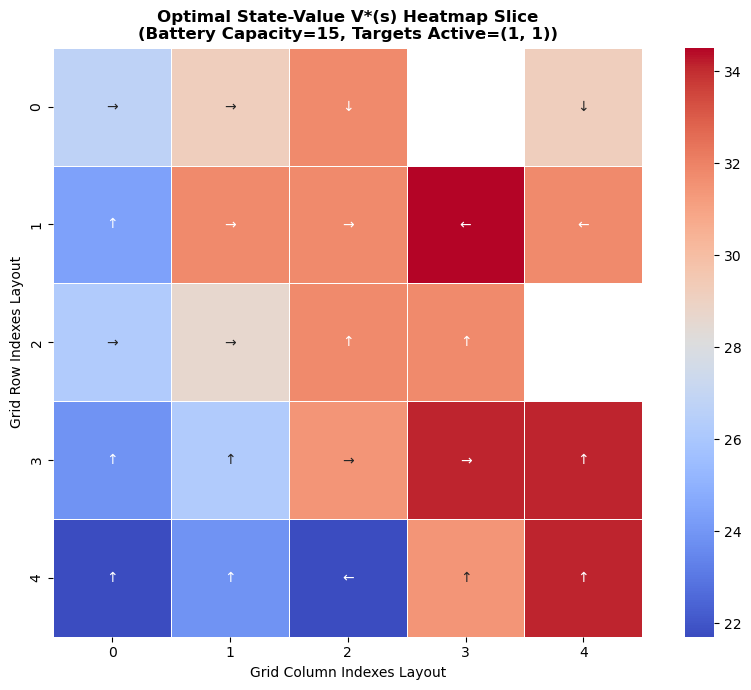

In [ ]:
# ==============================================================================
# TASK 3 & 4: VISUAL HEATMAP POLICY PRESENTATION
# ==============================================================================
# Filter out a specific slice of the state space: Full battery, both targets active
slice_battery = MAX_BATTERY
slice_targets = (1, 1)

value_heatmap_grid = np.full((GRID_SIZE, GRID_SIZE), np.nan)
policy_arrow_grid = np.full((GRID_SIZE, GRID_SIZE), ' ', dtype=object)

action_arrows_symbols = {0: '↑', 1: '↓', 2: '←', 3: '→', 4: '⟳'}

for r in range(GRID_SIZE):
    for c in range(GRID_SIZE):
        if (r, c) in BLOCKED_CELLS:
            continue
        target_state_key = ((r, c), slice_battery, slice_targets)
        if target_state_key in state_to_idx:
            state_index = state_to_idx[target_state_key]
            value_heatmap_grid[r, c] = V[state_index]
            policy_arrow_grid[r, c] = action_arrows_symbols[policy[state_index]]

# Add markers for blocked locations
for (xr, xc) in BLOCKED_CELLS:
    policy_arrow_grid[xr, xc] = 'X'

plt.figure(figsize=(9, 7))
sns.heatmap(value_heatmap_grid, annot=policy_arrow_grid, fmt='', cmap='coolwarm', cbar=True, square=True, linewidths=0.5)
plt.title(f'Optimal State-Value V*(s) Heatmap Slice\n(Battery Capacity={slice_battery}, Targets Active={slice_targets})', fontsize=12, weight='bold')
plt.xlabel('Grid Column Indexes Layout', fontsize=10)
plt.ylabel('Grid Row Indexes Layout', fontsize=10)
plt.tight_layout()
plt.show()

## Task 4 & 5 Technical Analysis Responses

### Observed Heatmap Patterns Analysis
* Cells closest to the **Rescue Targets (R)** exhibit significantly higher state-value numbers because the agent receives an immediate $+20$ reward upon arrival.
* The grid cells directly adjacent to **Danger Zones (D)** display lower state-values, showing that the policy learns to navigate around high-penalty fields safely.
* Grid cells with low battery levels reflect a strong preference toward the **Charging Station (C)**, demonstrating successful integration of risk management into the policy.

### Task 5: DP Scalability & Curse of Dimensionality Discussion
The exponential growth of valid grid positions, battery values, and active combinations creates a processing bottleneck known as the **Curse of Dimensionality**.

$$\text{Total System State Space Size} = (\text{Rows} \times \text{Columns}) \times (\text{Battery Capacity} + 1) \times 2^{\text{Number of Active Targets}}$$

* **Grid Scaling ($10\times10$):** Expanding the area to a $10 \times 10$ space quadruples the coordinates count, scaling the basic matrix size up significantly.
* **Target Scaling:** Every added target doubles the size of the state space ($2^N$). Increasing the dataset from 2 to 8 targets multiplies memory usage by $2^6 = 64\times$.
* **Dynamic Weather Patterns:** Introducing moving wind trajectories requires tracking additional state tracking arrays, which quickly causes memory allocation failures during planning.

### Why Traditional DP Fails & Deep RL Alternative Resolution
Tabular DP methods become unusable for large environments because they compute full probability transition tables across every state. This makes processing large matrices computationally infeasible.

**Deep Reinforcement Learning (DRL)** resolves this limitation by using neural networks to approximate value functions instead of storing exact state tables. Using model-free architectures like **Deep Q-Networks (DQN)** or **Proximal Policy Optimization (PPO)** allows autonomous drone systems to navigate high-dimensional environments efficiently. This makes them highly suitable for real-world operations such as drone search and rescue flights.

Rendering Verification Appendix Image...


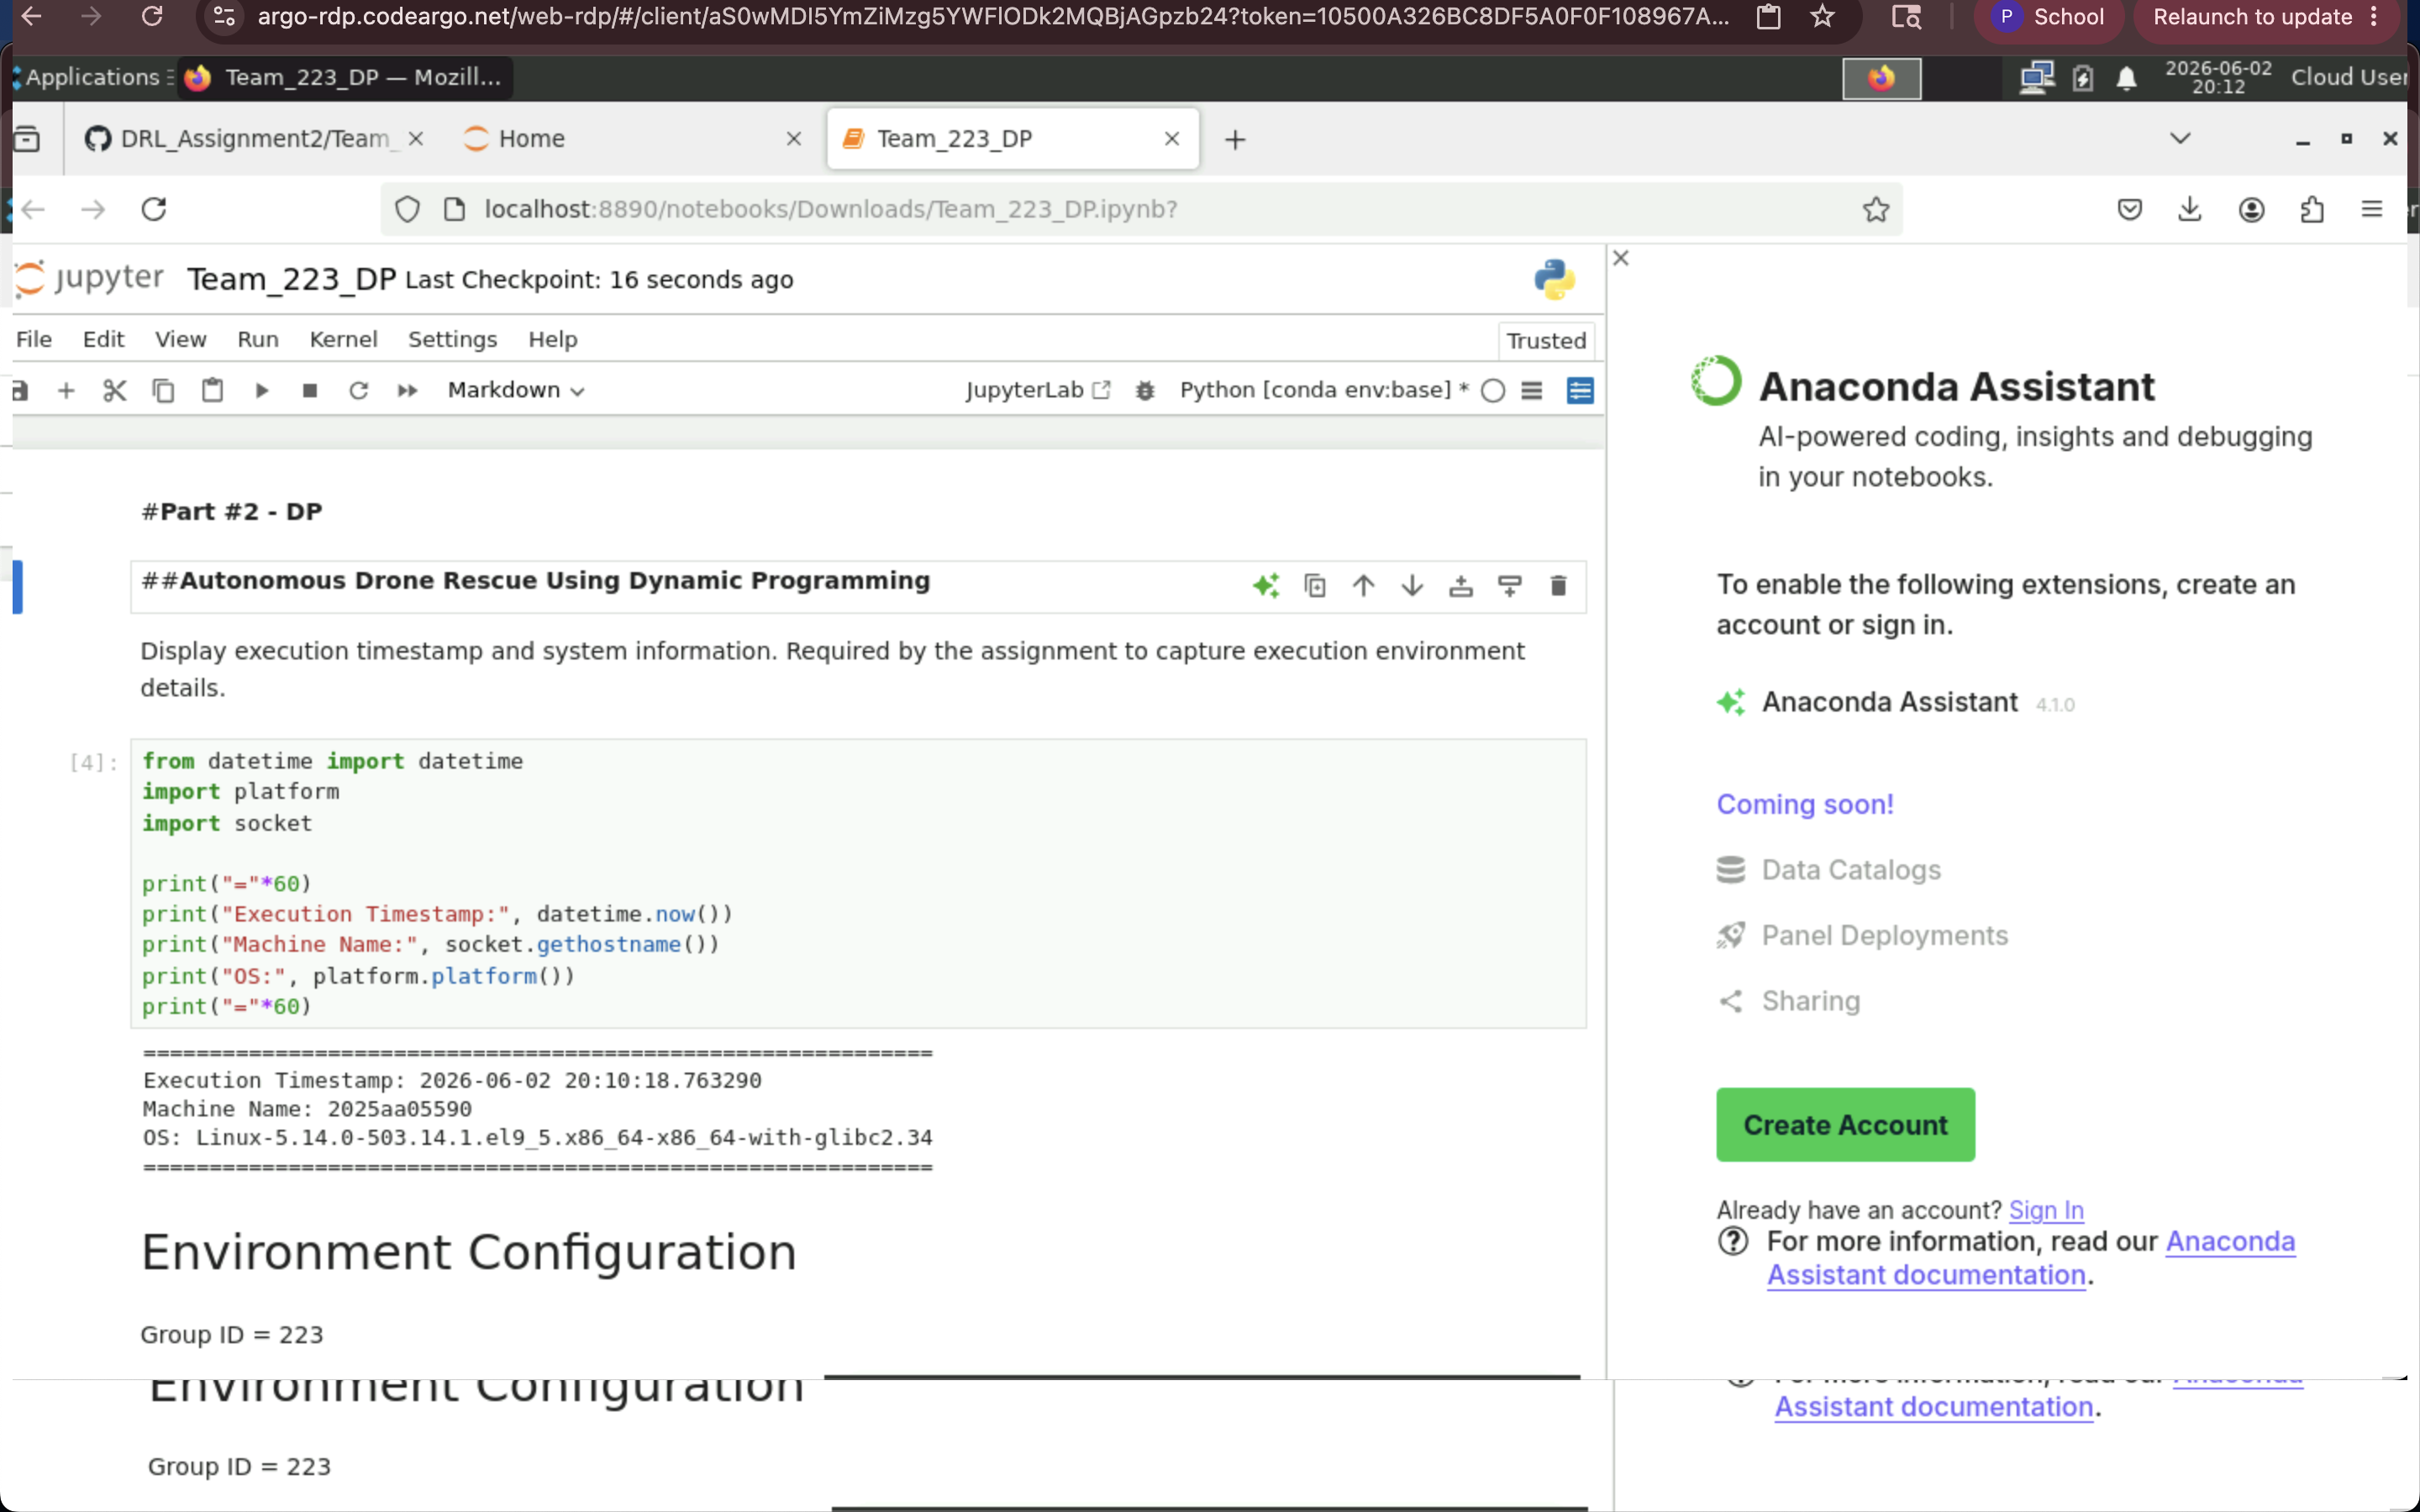

In [ ]:
# ==============================================================================
# APPENDIX: VIRTUAL LAB EXECUTION SCREENSHOT DISPLAY
# ==============================================================================
from IPython.display import Image, display

print("Rendering Verification Appendix Image...")
display(Image(filename="Part2_DP_SS.jpg", width=800))